In [1]:
# ============================================================
# MAPAS DE ANOMALIAS
# ============================================================
# Projeto: Monitoramento de Vegetação — Validação PRA
# Autora: Bruna Bertini
# Data: 2026
#
# Objetivo: Identificar anomalias nas 69 datas de 2020-2025,
#          comparando cada data com o padrão sazonal histórico.
#
# Metodologia:
#   anomalia = valor_data - média_sazonal_do_mesmo_mes
#   Classificação em 5 níveis por z-score
#
# IMPORTANTE: Não chamamos de anomalia climática ou histórica.
#             É anomalia estatística em relação ao padrão
#             sazonal observado (2020-2025).
# ============================================================

import rioxarray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
IND_DIR = BASE / "data" / "processed" / "indices"
RESULTS_DIR = BASE / "results"
RESULTS_DIR.mkdir(exist_ok=True)

CORES = {"NDVI": "#2ca02c", "EVI": "#1f77b4", "NDMI": "#ff7f0e"}

print(f"✓ Ambiente configurado")

✓ Ambiente configurado


In [2]:
# ============================================================
# CARREGAR SÉRIES COM ALINHAMENTO AUTOMÁTICO
# ============================================================
# Solução: realinhar todos os rasters à grade de referência
# (definida pelo primeiro arquivo de cada índice)
# ============================================================

import rioxarray
import numpy as np
import pandas as pd
import re
from pathlib import Path

BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
IND_DIR = BASE / "data" / "processed" / "indices"


def carregar_serie_alinhada(indice):
    """
    Carrega todas as datas intra-anuais de um índice,
    realinhando à grade do primeiro arquivo (referência).
    """
    
    pasta = IND_DIR / indice
    arquivos = sorted(f for f in pasta.glob(f"{indice}_*.tif")
                     if "mediana" not in f.name)
    
    # Usar o PRIMEIRO arquivo como grade de referência
    grade_ref = rioxarray.open_rasterio(arquivos[0]).squeeze()
    
    print(f"\n   Grade de referência ({arquivos[0].name}): {grade_ref.shape}")
    
    resultados = []
    rasters = []
    datas = []
    realinhados = 0
    erros = 0
    
    for arq in arquivos:
        match = re.search(r'(\d{8})', arq.stem)
        if not match:
            continue
        
        data_str = match.group(1)
        data = pd.to_datetime(data_str, format="%Y%m%d")
        
        r = rioxarray.open_rasterio(arq).squeeze()
        
        # Realinhar se shapes diferentes
        if r.shape != grade_ref.shape:
            try:
                r = r.rio.reproject_match(grade_ref)
                realinhados += 1
            except Exception as e:
                print(f"   ⚠️ Erro ao realinhar {arq.name}: {e}")
                erros += 1
                continue
        
        vals = r.values
        rasters.append(vals)
        datas.append(data)
        
        vals_validos = vals[~np.isnan(vals)]
        
        resultados.append({
            "data": data,
            "data_str": data_str,
            "ano": data.year,
            "mes": data.month,
            "media": vals_validos.mean(),
            "mediana": np.median(vals_validos),
            "std": vals_validos.std(),
            "n_pixels": len(vals_validos)
        })
    
    df = pd.DataFrame(resultados).sort_values("data").reset_index(drop=True)
    cubo = np.stack(rasters, axis=0)
    
    print(f"   ✓ {len(df)} datas carregadas")
    print(f"   ✓ {realinhados} realinhadas, {erros} com erro")
    print(f"   ✓ Cubo: {cubo.shape}")
    
    return df, cubo, datas


# ============================================================
# Carregar com alinhamento
# ============================================================
print("=" * 80)
print("CARREGANDO SÉRIES INTRA-ANUAIS (COM ALINHAMENTO)")
print("=" * 80)

series = {}
cubos = {}
datas_ref = None

for indice in ["ndvi", "evi", "ndmi"]:
    print(f"\n📁 Processando {indice.upper()}...")
    df, cubo, datas = carregar_serie_alinhada(indice)
    series[indice.upper()] = df
    cubos[indice.upper()] = cubo
    
    if datas_ref is None:
        datas_ref = datas
    
    print(f"   Período: {df['data'].min().strftime('%Y-%m-%d')} a {df['data'].max().strftime('%Y-%m-%d')}")

# Bounds
ndvi_ref = rioxarray.open_rasterio(IND_DIR / "ndvi" / "ndvi_mediana_2025.tif").squeeze()
left, bottom, right, top = ndvi_ref.rio.bounds()
print(f"\nBounds: {left:.0f}, {bottom:.0f}, {right:.0f}, {top:.0f}")

CARREGANDO SÉRIES INTRA-ANUAIS (COM ALINHAMENTO)

📁 Processando NDVI...

   Grade de referência (ndvi_20200115.tif): (222, 140)
   ✓ 69 datas carregadas
   ✓ 18 realinhadas, 0 com erro
   ✓ Cubo: (69, 222, 140)
   Período: 2020-01-15 a 2025-12-04

📁 Processando EVI...

   Grade de referência (evi_20200115.tif): (222, 140)
   ✓ 69 datas carregadas
   ✓ 0 realinhadas, 0 com erro
   ✓ Cubo: (69, 222, 140)
   Período: 2020-01-15 a 2025-12-04

📁 Processando NDMI...

   Grade de referência (ndmi_20200115.tif): (112, 71)
   ✓ 69 datas carregadas
   ✓ 18 realinhadas, 0 com erro
   ✓ Cubo: (69, 112, 71)
   Período: 2020-01-15 a 2025-12-04

Bounds: 852790, 7398810, 854190, 7401030


In [3]:
# ============================================================
# PADRÃO SAZONAL HISTÓRICO (2020-2025)
# ============================================================
# Média de cada mês usando as 69 datas (todos os anos)
# ============================================================

sazonais = {}

print("=" * 90)
print("PADRÃO SAZONAL HISTÓRICO (2020-2025)")
print("=" * 90)

for indice in ["NDVI", "EVI", "NDMI"]:
    df = series[indice]
    
    # Média por mês (usando todas as datas)
    sazonal = df.groupby("mes").agg(
        media=("media", "mean"),
        std=("media", "std"),
        n=("media", "count")
    ).reset_index()
    
    sazonais[indice] = sazonal
    
    print(f"\n📊 {indice}")
    print(sazonal.to_string(index=False, float_format="%.3f"))

# Salvar
for indice, sazonal in sazonais.items():
    output = RESULTS_DIR / f"sazonalidade_{indice.lower()}_historica.csv"
    sazonal.to_csv(output, index=False)

print(f"\n✅ Padrões sazonais salvos em {RESULTS_DIR}")

PADRÃO SAZONAL HISTÓRICO (2020-2025)

📊 NDVI
 mes  media   std  n
   1  0.414 0.080  5
   2  0.486 0.057  5
   3  0.390 0.083  6
   4  0.338 0.063  6
   5  0.332 0.027  6
   6  0.385 0.050  6
   7  0.397 0.034  6
   8  0.344 0.040  6
   9  0.283 0.039  6
  10  0.286 0.043  6
  11  0.312 0.026  6
  12  0.393 0.090  5

📊 EVI
 mes  media   std  n
   1  0.302 0.066  5
   2  0.403 0.112  5
   3  0.329 0.101  6
   4  0.209 0.049  6
   5  0.208 0.047  6
   6  0.281 0.074  6
   7  0.254 0.081  6
   8  0.272 0.071  6
   9  0.196 0.054  6
  10  0.188 0.037  6
  11  0.224 0.050  6
  12  0.354 0.207  5

📊 NDMI
 mes  media   std  n
   1  0.108 0.073  5
   2  0.174 0.053  5
   3  0.072 0.092  6
   4  0.031 0.073  6
   5  0.007 0.030  6
   6  0.053 0.053  6
   7  0.075 0.036  6
   8  0.022 0.047  6
   9 -0.028 0.028  6
  10 -0.035 0.038  6
  11 -0.006 0.015  6
  12  0.084 0.085  5

✅ Padrões sazonais salvos em C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results


In [4]:
# ============================================================
# 8.1 — ANOMALIA POR DATA
# ============================================================
# anomalia = valor_data - média_sazonal_do_mesmo_mes
# Classificação em 5 níveis por z-score
# ============================================================

def classificar_anomalia(z):
    """Classifica anomalia pelo z-score."""
    if z > 1.5:
        return "Muito acima"
    elif z > 0.5:
        return "Acima"
    elif z < -1.5:
        return "Muito abaixo"
    elif z < -0.5:
        return "Abaixo"
    else:
        return "Normal"


dfs_anomalias = {}

print("=" * 90)
print("8.1 — ANOMALIA POR DATA (2020-2025)")
print("=" * 90)

for indice in ["NDVI", "EVI", "NDMI"]:
    df = series[indice].copy()
    sazonal = sazonais[indice]
    
    # Mapear média e std sazonal por mês
    df = df.merge(
        sazonal.rename(columns={"media": "media_sazonal", "std": "std_sazonal"}),
        on="mes",
        how="left"
    )
    
    # Calcular anomalia
    df["anomalia"] = df["media"] - df["media_sazonal"]
    
    # Z-score (evitando divisão por zero)
    df["z_score"] = np.where(
        df["std_sazonal"] > 0.001,
        df["anomalia"] / df["std_sazonal"],
        np.nan
    )
    
    # Classificação
    df["classificacao"] = df["z_score"].apply(classificar_anomalia)
    
    dfs_anomalias[indice] = df
    
    # Resumo
    print(f"\n📊 {indice}")
    print(f"   Média das anomalias: {df['anomalia'].mean():+.3f}")
    print(f"   Std das anomalias:   {df['anomalia'].std():.3f}")
    print(f"\n   Distribuição das classes:")
    for classe in ["Muito acima", "Acima", "Normal", "Abaixo", "Muito abaixo"]:
        n = (df["classificacao"] == classe).sum()
        pct = n / len(df) * 100
        print(f"      {classe:<15} {n:>3} datas ({pct:.1f}%)")
    
    # Top 5 anomalias positivas e negativas
    print(f"\n   Top 5 anomalias POSITIVAS:")
    top_pos = df.nlargest(5, "anomalia")[["data_str", "media", "media_sazonal", "anomalia", "classificacao"]]
    print(top_pos.to_string(index=False, float_format="%.3f"))
    
    print(f"\n   Top 5 anomalias NEGATIVAS:")
    top_neg = df.nsmallest(5, "anomalia")[["data_str", "media", "media_sazonal", "anomalia", "classificacao"]]
    print(top_neg.to_string(index=False, float_format="%.3f"))

# Salvar
df_anomalias_concat = pd.concat(
    dfs_anomalias.values(),
    keys=dfs_anomalias.keys(),
    names=["indice"]
)
output = RESULTS_DIR / "anomalias_por_data.csv"
df_anomalias_concat.to_csv(output)
print(f"\n✅ Salvo: {output}")

8.1 — ANOMALIA POR DATA (2020-2025)

📊 NDVI
   Média das anomalias: +0.000
   Std das anomalias:   0.051

   Distribuição das classes:
      Muito acima       5 datas (7.2%)
      Acima            16 datas (23.2%)
      Normal           24 datas (34.8%)
      Abaixo           20 datas (29.0%)
      Muito abaixo      4 datas (5.8%)

   Top 5 anomalias POSITIVAS:
data_str  media  media_sazonal  anomalia classificacao
20200325  0.522          0.390     0.132   Muito acima
20200404  0.462          0.338     0.124   Muito acima
20220119  0.521          0.414     0.107         Acima
20221210  0.484          0.393     0.091         Acima
20231011  0.357          0.286     0.071   Muito acima

   Top 5 anomalias NEGATIVAS:
data_str  media  media_sazonal  anomalia classificacao
20251204  0.255          0.393    -0.138  Muito abaixo
20200115  0.309          0.414    -0.105        Abaixo
20200613  0.288          0.385    -0.098  Muito abaixo
20210223  0.394          0.486    -0.092  Muito abaixo


✅ Gráfico salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\anomalias_por_data.png


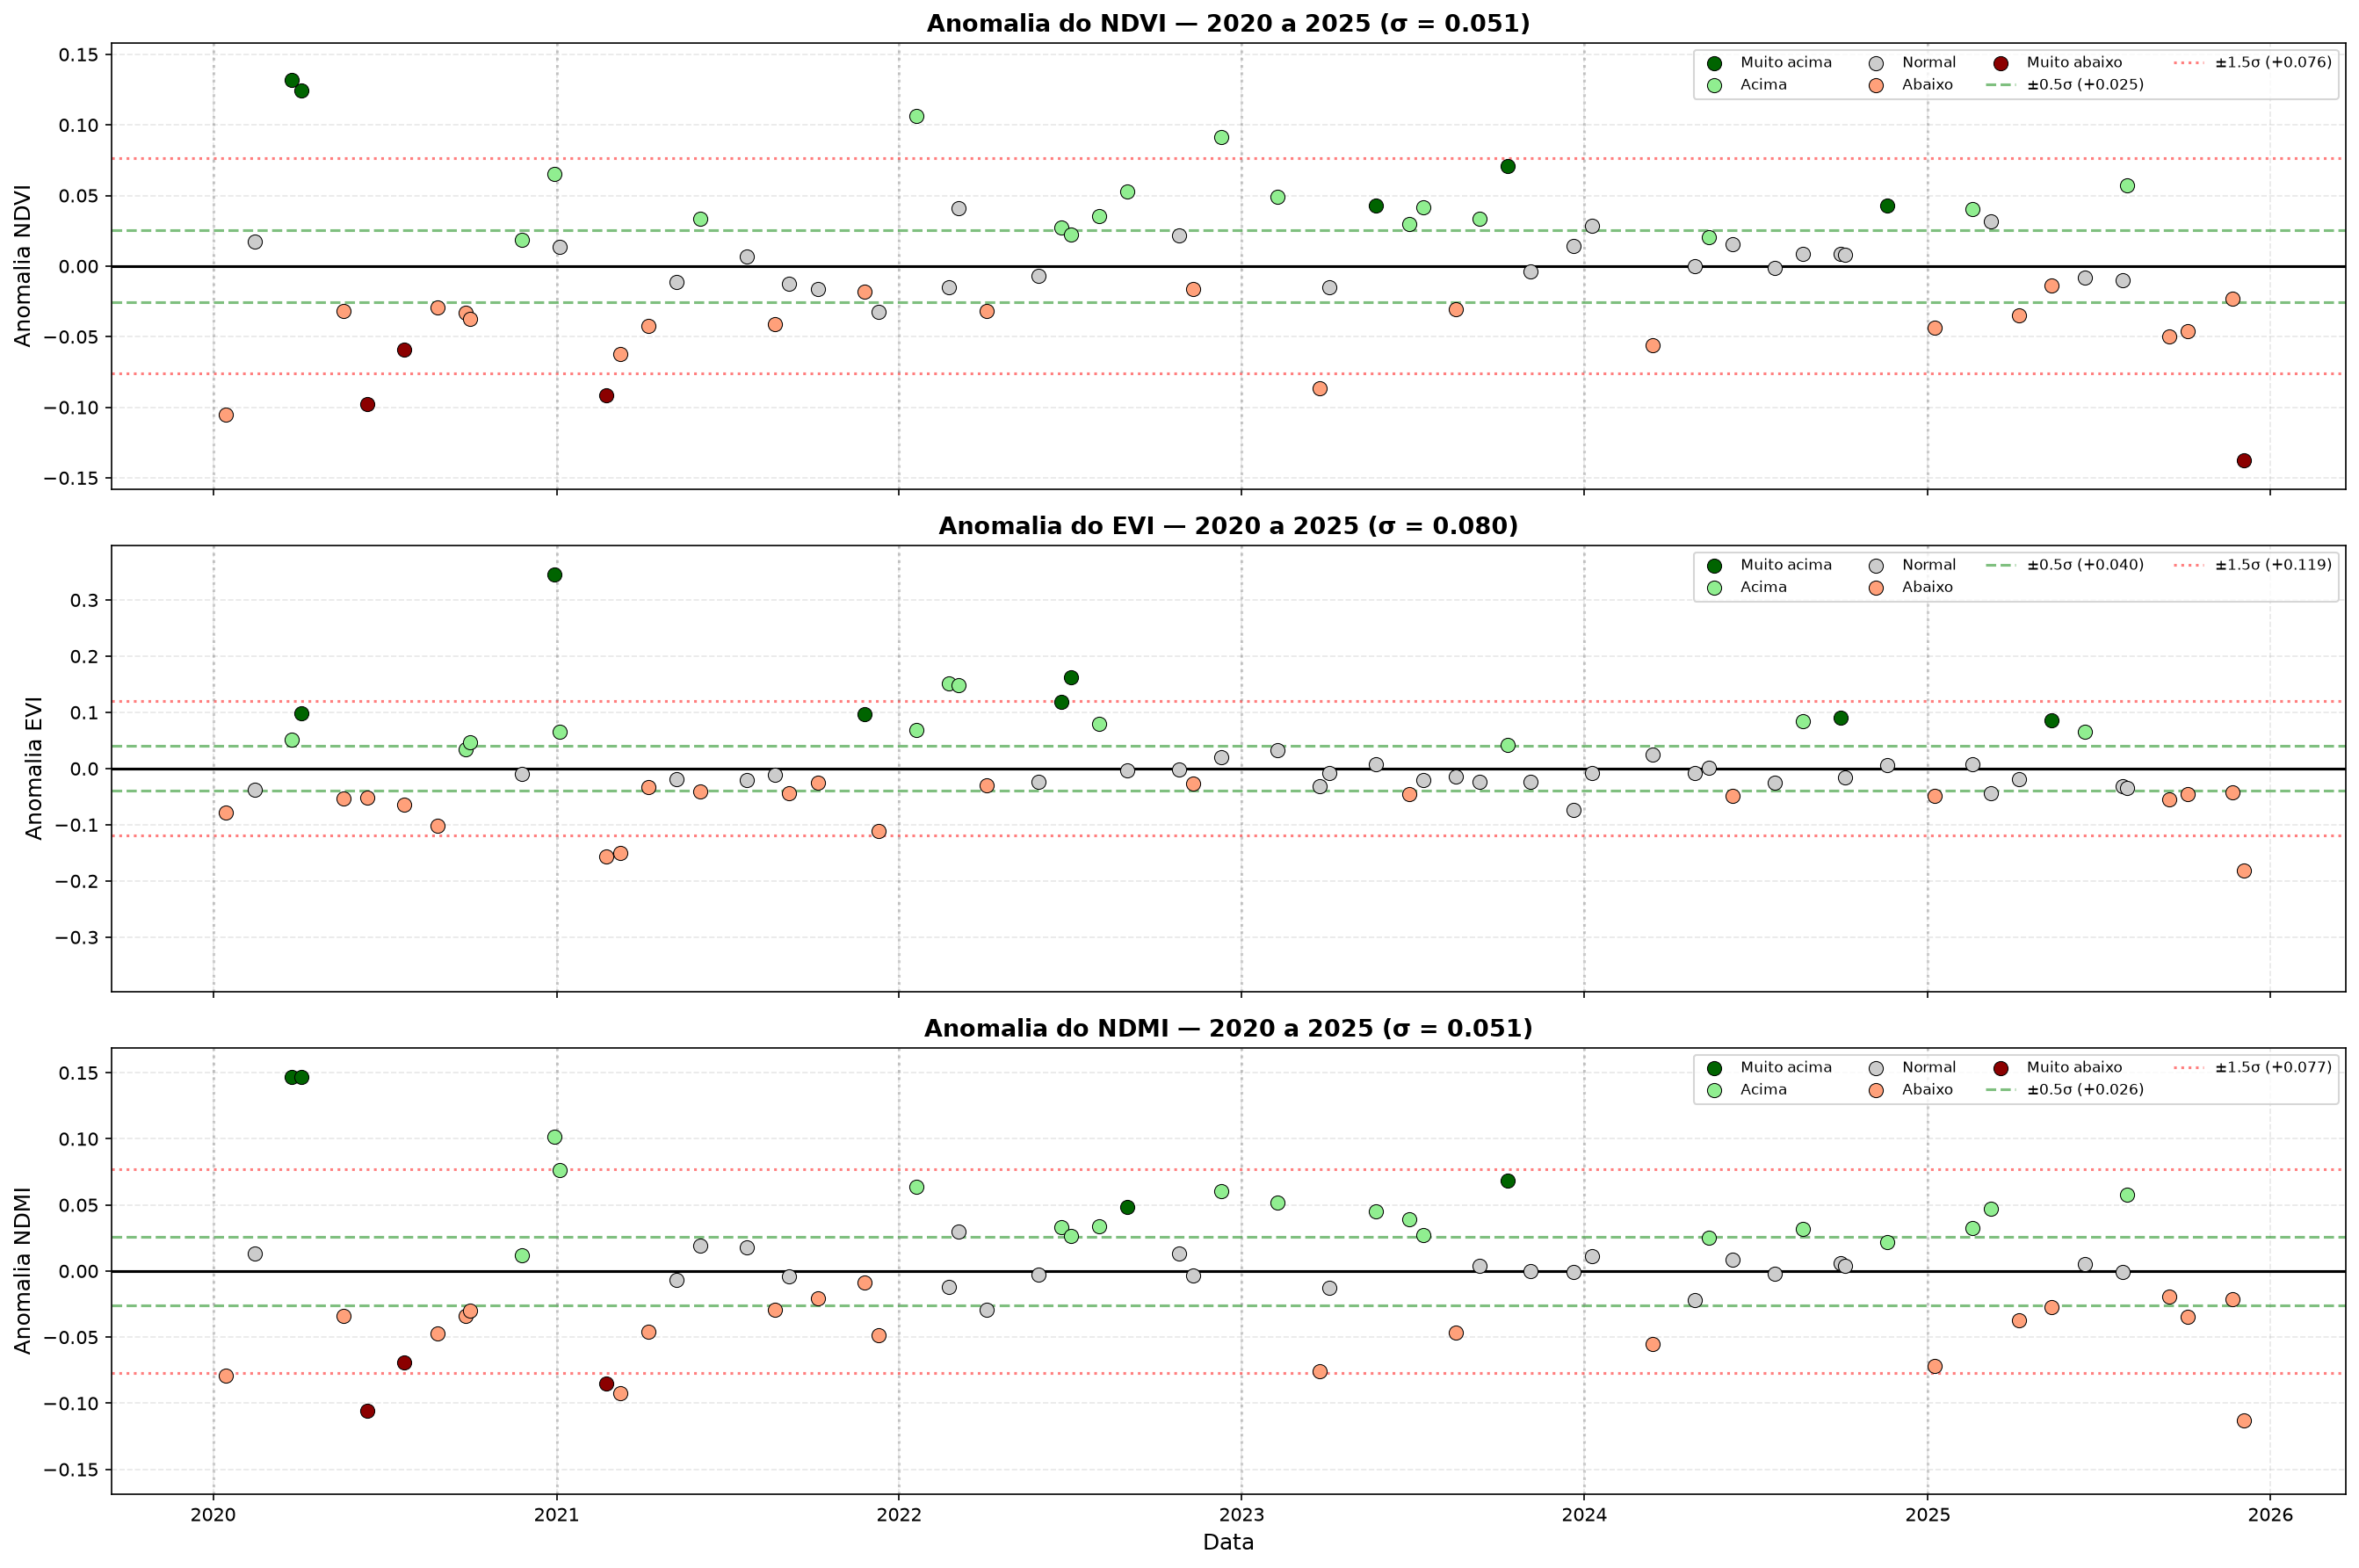

In [5]:
# ============================================================
# GRÁFICO — ANOMALIA POR DATA (2020-2025) — ESCALA CORRIGIDA
# ============================================================

cores_anom = {
    "Muito acima": "#006400",
    "Acima": "#90EE90",
    "Normal": "#CCCCCC",
    "Abaixo": "#FFA07A",
    "Muito abaixo": "#8B0000"
}

fig, axes = plt.subplots(3, 1, figsize=(18, 12), dpi=150, sharex=True)

for ax, indice in zip(axes, ["NDVI", "EVI", "NDMI"]):
    df = dfs_anomalias[indice]
    
    # Calcular o desvio padrão REAL das anomalias desse índice
    std_real = df["anomalia"].std()
    
    # Definir limites da escala com base nos dados reais
    lim = max(abs(df["anomalia"].min()), abs(df["anomalia"].max())) * 1.15
    
    # Separar por classe
    for classe, cor in cores_anom.items():
        mask = df["classificacao"] == classe
        if mask.sum() > 0:
            ax.scatter(df.loc[mask, "data"], df.loc[mask, "anomalia"],
                       c=cor, s=60, edgecolor="black", linewidth=0.5,
                       label=classe, zorder=3)
    
    # Linhas de referência em desvios padrão REAIS
    ax.axhline(0, color="black", linewidth=1.5)
    ax.axhline(+0.5 * std_real, color="green", linestyle="--", 
               alpha=0.5, label=f"±0.5σ ({0.5*std_real:+.3f})")
    ax.axhline(-0.5 * std_real, color="green", linestyle="--", alpha=0.5)
    ax.axhline(+1.5 * std_real, color="red", linestyle=":", 
               alpha=0.5, label=f"±1.5σ ({1.5*std_real:+.3f})")
    ax.axhline(-1.5 * std_real, color="red", linestyle=":", alpha=0.5)
    
    # Separadores por ano
    for ano in range(2020, 2026):
        ax.axvline(pd.Timestamp(f"{ano}-01-01"), color="gray",
                   linestyle=":", alpha=0.4)
    
    # Fixar limites da escala
    ax.set_ylim(-lim, lim)
    
    ax.set_ylabel(f"Anomalia {indice}", fontsize=12)
    ax.set_title(f"Anomalia do {indice} — 2020 a 2025 (σ = {std_real:.3f})",
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="upper right", fontsize=8, ncol=4)

axes[-1].set_xlabel("Data", fontsize=12)
plt.tight_layout()

output = RESULTS_DIR / "anomalias_por_data.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico salvo: {output}")

plt.show()

In [6]:
# ============================================================
# CORREÇÃO DEFINITIVA — ANOMALIA TEMPORAL POR PIXEL
# ============================================================
# A anomalia correta é:
#   anomalia_data = valor_pixel_na_data - média_do_pixel_no_mesmo_mes
# ============================================================

resultados_espaciais = {}

print("=" * 90)
print("8.2 — ANOMALIA ESPACIAL (VERSÃO DEFINITIVA)")
print("=" * 90)

for indice in ["NDVI", "EVI", "NDMI"]:
    df = dfs_anomalias[indice]
    cubo = cubos[indice]
    
    n_datas, h, w = cubo.shape
    meses = df["mes"].values
    
    # Para cada mês, calcular a MÉDIA TEMPORAL POR PIXEL
    # (média do pixel em todas as datas daquele mês)
    media_por_mes_pixel = {}
    
    for mes in range(1, 13):
        idx_mes = np.where(meses == mes)[0]
        if len(idx_mes) == 0:
            continue
        
        # Média temporal do pixel (ao longo das datas desse mês)
        media_mes = np.nanmean(cubo[idx_mes], axis=0)
        media_por_mes_pixel[mes] = media_mes
    
    # Calcular anomalia para cada data
    cubo_anomalia = np.full_like(cubo, np.nan, dtype=np.float32)
    
    for i, mes in enumerate(meses):
        if mes in media_por_mes_pixel:
            cubo_anomalia[i] = cubo[i] - media_por_mes_pixel[mes]
    
    # Frequências
    freq_negativa = np.nanmean(cubo_anomalia < -0.05, axis=0) * 100
    freq_positiva = np.nanmean(cubo_anomalia > 0.05, axis=0) * 100
    
    # Anomalia média por pixel
    anomalia_media = np.nanmean(cubo_anomalia, axis=0)
    anomalia_std = np.nanstd(cubo_anomalia, axis=0)
    
    resultados_espaciais[indice] = {
        "anomalia_media": anomalia_media,
        "anomalia_std": anomalia_std,
        "freq_negativa": freq_negativa,
        "freq_positiva": freq_positiva,
        "cubo_anomalia": cubo_anomalia
    }
    
    # Diagnóstico
    validos = cubo_anomalia[~np.isnan(cubo_anomalia)]
    sempre_neg = np.all(cubo_anomalia < -0.05, axis=0)
    
    print(f"\n📊 {indice}")
    print(f"   Std do cubo: {validos.std():.4f}")
    print(f"   Pixels sempre negativos: {sempre_neg.sum()} ({sempre_neg.sum()/sempre_neg.size*100:.1f}%)")
    print(f"   Frequência negativa média: {np.nanmean(freq_negativa):.1f}%")
    print(f"   Frequência positiva média: {np.nanmean(freq_positiva):.1f}%")

8.2 — ANOMALIA ESPACIAL (VERSÃO DEFINITIVA)

📊 NDVI
   Std do cubo: 0.1072
   Pixels sempre negativos: 0 (0.0%)
   Frequência negativa média: 18.6%
   Frequência positiva média: 18.2%

📊 EVI
   Std do cubo: 0.1008
   Pixels sempre negativos: 0 (0.0%)
   Frequência negativa média: 17.2%
   Frequência positiva média: 15.5%

📊 NDMI
   Std do cubo: 0.1013
   Pixels sempre negativos: 0 (0.0%)
   Frequência negativa média: 18.6%
   Frequência positiva média: 17.4%


In [7]:
# ============================================================
# CORREÇÃO — ANOMALIA ESPACIAL (VERSÃO CORRETA)
# ============================================================
# A anomalia deve ser calculada em relação ao PADRÃO SAZONAL,
# não em relação à média do próprio pixel.
# ============================================================

resultados_espaciais = {}

print("=" * 90)
print("8.2 — ANOMALIA ESPACIAL (VERSÃO CORRIGIDA)")
print("=" * 90)

for indice in ["NDVI", "EVI", "NDMI"]:
    df = dfs_anomalias[indice]
    cubo = cubos[indice]
    sazonal = sazonais[indice]
    
    n_datas, h, w = cubo.shape
    meses = df["mes"].values
    
    # Mapear média sazonal por mês (média espacial do mês)
    medias_sazonais = sazonal.set_index("mes")["media"].to_dict()
    
    # Calcular anomalia para cada data
    # anomalia = valor_pixel - media_espacial_do_mesmo_mes
    cubo_anomalia = np.full_like(cubo, np.nan, dtype=np.float32)
    
    for i, mes in enumerate(meses):
        if mes in medias_sazonais:
            cubo_anomalia[i] = cubo[i] - medias_sazonais[mes]
    
    # Agora sim: frequências que fazem sentido
    freq_negativa = np.nanmean(cubo_anomalia < -0.05, axis=0) * 100
    freq_positiva = np.nanmean(cubo_anomalia > 0.05, axis=0) * 100
    
    # Anomalia média (agora não é zero)
    anomalia_media = np.nanmean(cubo_anomalia, axis=0)
    
    # Variabilidade
    anomalia_std = np.nanstd(cubo_anomalia, axis=0)
    
    resultados_espaciais[indice] = {
        "anomalia_media": anomalia_media,
        "anomalia_std": anomalia_std,
        "freq_negativa": freq_negativa,
        "freq_positiva": freq_positiva,
        "cubo_anomalia": cubo_anomalia
    }
    
    # Verificação: soma das frequências não pode passar de 100%
    freq_soma = freq_negativa + freq_positiva
    
    print(f"\n📊 {indice}")
    print(f"   Anomalia média: {np.nanmean(anomalia_media):+.4f}")
    print(f"   Frequência negativa média: {np.nanmean(freq_negativa):.1f}%")
    print(f"   Frequência positiva média: {np.nanmean(freq_positiva):.1f}%")
    print(f"   Soma das frequências:     {np.nanmean(freq_soma):.1f}%")
    print(f"   → Se soma > 100%, há pixels com anomalia em ambos sentidos")

8.2 — ANOMALIA ESPACIAL (VERSÃO CORRIGIDA)

📊 NDVI
   Anomalia média: +0.0000
   Frequência negativa média: 47.4%
   Frequência positiva média: 45.3%
   Soma das frequências:     92.6%
   → Se soma > 100%, há pixels com anomalia em ambos sentidos

📊 EVI
   Anomalia média: -0.0335
   Frequência negativa média: 40.2%
   Frequência positiva média: 37.6%
   Soma das frequências:     77.8%
   → Se soma > 100%, há pixels com anomalia em ambos sentidos

📊 NDMI
   Anomalia média: -0.0000
   Frequência negativa média: 41.4%
   Frequência positiva média: 30.1%
   Soma das frequências:     71.5%
   → Se soma > 100%, há pixels com anomalia em ambos sentidos


In [8]:
# ============================================================
# 8.3 — HOTSPOTS DE ANOMALIA (VERSÃO FINAL)
# ============================================================
# Metodologia:
#   - Para cada pixel, calcular anomalia média temporal
#   - Definir limiares por desvio padrão da anomalia
#   - Clusterizar pixels extremos
# ============================================================

from scipy.ndimage import label

resultados_hotspots = {}

print("=" * 90)
print("8.3 — HOTSPOTS DE ANOMALIA PERSISTENTE")
print("=" * 90)

for indice in ["NDVI", "EVI", "NDMI"]:
    anomalia = resultados_espaciais[indice]["anomalia_media"]
    
    # Usar desvio padrão da anomalia como referência
    std_anom = np.nanstd(anomalia)
    
    # Limiares: ±1.5 desvios padrão (mais rigoroso)
    limiar_neg = -1.5 * std_anom
    limiar_pos = +1.5 * std_anom
    
    print(f"\n📊 {indice}")
    print(f"   Std da anomalia: {std_anom:.4f}")
    print(f"   Limiar negativo: {limiar_neg:+.4f} (1.5σ)")
    print(f"   Limiar positivo: {limiar_pos:+.4f} (1.5σ)")
    
    # Máscara de hotspots
    mask_neg = anomalia < limiar_neg
    mask_pos = anomalia > limiar_pos
    
    # Contagem
    n_neg = mask_neg.sum()
    n_pos = mask_pos.sum()
    
    # Clusterizar
    labeled_neg, _ = label(mask_neg, structure=np.ones((3, 3)))
    labeled_pos, _ = label(mask_pos, structure=np.ones((3, 3)))
    
    # Área do pixel
    area_pixel_ha = 0.04 if indice == "NDMI" else 0.01
    
    # Filtrar clusters < 0.5 ha
    def filtrar_clusters(labeled):
        clusters = []
        n_clusters = labeled.max()
        for i in range(1, n_clusters + 1):
            mask = labeled == i
            n_pixels = mask.sum()
            area = n_pixels * area_pixel_ha
            if area >= 0.5:
                clusters.append({"id": i, "n_pixels": n_pixels, "area_ha": area})
        return clusters
    
    hotspots_neg = filtrar_clusters(labeled_neg)
    hotspots_pos = filtrar_clusters(labeled_pos)
    
    resultados_hotspots[indice] = {
        "labeled_neg": labeled_neg,
        "labeled_pos": labeled_pos,
        "hotspots_neg": hotspots_neg,
        "hotspots_pos": hotspots_pos,
        "limiar_neg": limiar_neg,
        "limiar_pos": limiar_pos
    }
    
    area_neg = sum(h["area_ha"] for h in hotspots_neg)
    area_pos = sum(h["area_ha"] for h in hotspots_pos)
    
    print(f"   Pixels acima do limiar: {n_neg} neg, {n_pos} pos")
    print(f"   Hotspots NEGATIVOS: {len(hotspots_neg)} clusters ({area_neg:.2f} ha)")
    print(f"   Hotspots POSITIVOS: {len(hotspots_pos)} clusters ({area_pos:.2f} ha)")


# ============================================================
# Resumo
# ============================================================
resumo = []
for indice in ["NDVI", "EVI", "NDMI"]:
    r = resultados_hotspots[indice]
    resumo.append({
        "Índice": indice,
        "N hotspots neg": len(r["hotspots_neg"]),
        "Área neg (ha)": sum(h["area_ha"] for h in r["hotspots_neg"]),
        "N hotspots pos": len(r["hotspots_pos"]),
        "Área pos (ha)": sum(h["area_ha"] for h in r["hotspots_pos"])
    })

df_hotspots = pd.DataFrame(resumo)
print("\n" + "=" * 90)
print("RESUMO DOS HOTSPOTS")
print("=" * 90)
print(df_hotspots.to_string(index=False, float_format="%.2f"))

output = RESULTS_DIR / "hotspots_anomalia.csv"
df_hotspots.to_csv(output, index=False)
print(f"\n✅ Salvo: {output}")

8.3 — HOTSPOTS DE ANOMALIA PERSISTENTE

📊 NDVI
   Std da anomalia: 0.3024
   Limiar negativo: -0.4537 (1.5σ)
   Limiar positivo: +0.4537 (1.5σ)
   Pixels acima do limiar: 0 neg, 1436 pos
   Hotspots NEGATIVOS: 0 clusters (0.00 ha)
   Hotspots POSITIVOS: 7 clusters (13.22 ha)

📊 EVI
   Std da anomalia: 0.1864
   Limiar negativo: -0.2796 (1.5σ)
   Limiar positivo: +0.2796 (1.5σ)
   Pixels acima do limiar: 0 neg, 299 pos
   Hotspots NEGATIVOS: 0 clusters (0.00 ha)
   Hotspots POSITIVOS: 0 clusters (0.00 ha)

📊 NDMI
   Std da anomalia: 0.1051
   Limiar negativo: -0.1576 (1.5σ)
   Limiar positivo: +0.1576 (1.5σ)
   Pixels acima do limiar: 1 neg, 1090 pos
   Hotspots NEGATIVOS: 0 clusters (0.00 ha)
   Hotspots POSITIVOS: 4 clusters (42.64 ha)

RESUMO DOS HOTSPOTS
Índice  N hotspots neg  Área neg (ha)  N hotspots pos  Área pos (ha)
  NDVI               0              0               7          13.22
   EVI               0              0               0           0.00
  NDMI               0   

In [9]:
# ============================================================
# RESUMO FINAL — ETAPA 8
# ============================================================

print("=" * 90)
print("RESUMO — ETAPA 8 (ANOMALIAS 2020-2025)")
print("=" * 90)

print(f"\n✓ Produtos gerados em: {RESULTS_DIR}")

print(f"\n📄 Arquivos CSV:")
for f in sorted(RESULTS_DIR.glob("*.csv")):
    tamanho = f.stat().st_size / 1024
    print(f"   - {f.name} ({tamanho:.1f} KB)")

print(f"\n🖼️ Arquivos PNG:")
for f in sorted(RESULTS_DIR.glob("*.png")):
    tamanho = f.stat().st_size / 1024
    print(f"   - {f.name} ({tamanho:.1f} KB)")

print("\n" + "=" * 90)
print("SÍNTESE — ANOMALIAS POR DATA")
print("=" * 90)

for indice in ["NDVI", "EVI", "NDMI"]:
    df = dfs_anomalias[indice]
    n_normal = (df["classificacao"] == "Normal").sum()
    n_acima = (df["classificacao"].isin(["Acima", "Muito acima"])).sum()
    n_abaixo = (df["classificacao"].isin(["Abaixo", "Muito abaixo"])).sum()
    
    print(f"\n📊 {indice}:")
    print(f"   Normal:  {n_normal:>3} datas ({n_normal/len(df)*100:.1f}%)")
    print(f"   Acima:   {n_acima:>3} datas ({n_acima/len(df)*100:.1f}%)")
    print(f"   Abaixo:  {n_abaixo:>3} datas ({n_abaixo/len(df)*100:.1f}%)")

print(f"\n✓ Etapa 8 concluída")
print(f"✓ Próximo: Etapa 9 — Análise por Zonas Ambientais")

RESUMO — ETAPA 8 (ANOMALIAS 2020-2025)

✓ Produtos gerados em: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results

📄 Arquivos CSV:
   - anomalias_por_data.csv (37.8 KB)
   - correlacao_indices.csv (0.2 KB)
   - estatisticas_espaciais.csv (0.3 KB)
   - hotspots_anomalia.csv (0.1 KB)
   - sazonalidade.csv (2.3 KB)
   - sazonalidade_evi_historica.csv (0.5 KB)
   - sazonalidade_ndmi_historica.csv (0.4 KB)
   - sazonalidade_ndvi_historica.csv (0.3 KB)
   - serie_anual_completa.csv (1.7 KB)
   - serie_intraanual_completa.csv (30.9 KB)

🖼️ Arquivos PNG:
   - 08_mapa_comparativo_anomalias.png (897.9 KB)
   - 08_mapa_freq_corrigido.png (899.3 KB)
   - 08_mapa_freq_negativa.png (544.5 KB)
   - 08_mapa_variabilidade_anomalia.png (597.7 KB)
   - anomalias_por_data.png (635.3 KB)
   - histogramas_comparativos.png (220.7 KB)
   - mapa_anomalia_espacial.png (491.9 KB)
   - mapa_caracterizacao_ambiental.png (878.3 KB)
   - mapa_hotspots.png (542.1 KB)
   - matriz_correlacao.png (10

✅ Gráfico salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\08_mapa_freq_corrigido.png


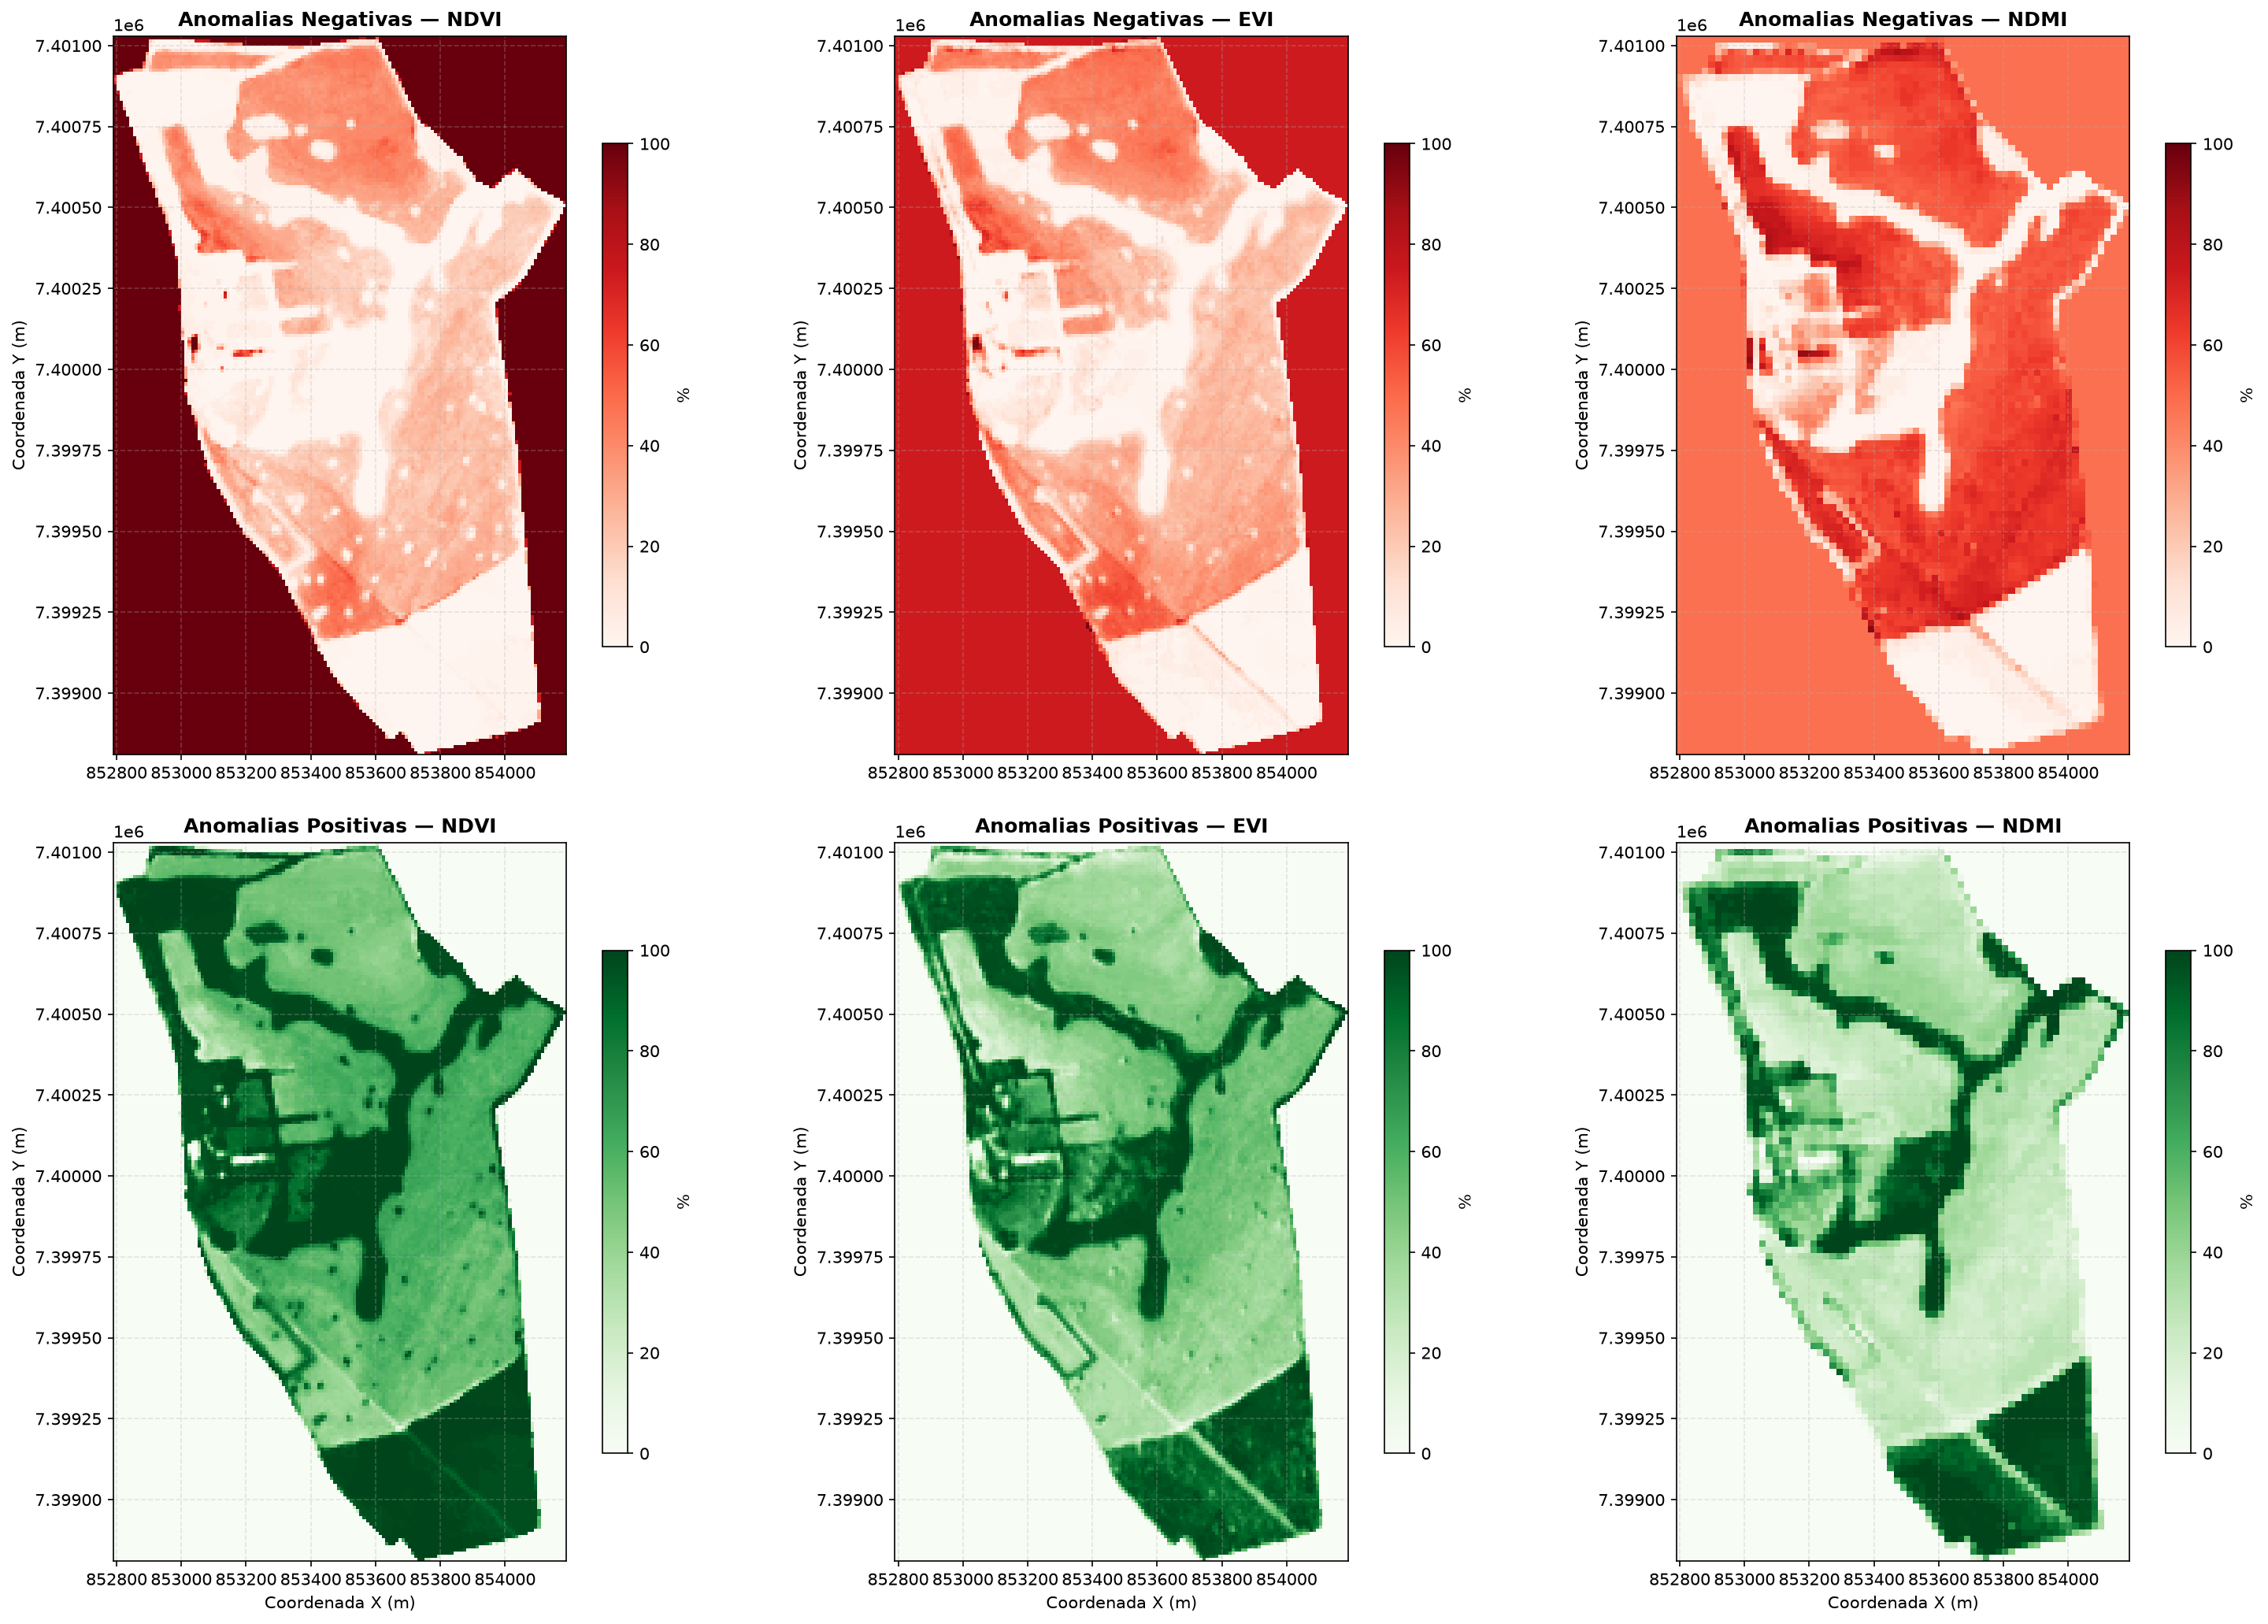

In [10]:
# ============================================================
# MAPAS CORRIGIDOS — FREQUÊNCIAS COMPLEMENTARES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 14), dpi=150)

for i, indice in enumerate(["NDVI", "EVI", "NDMI"]):
    # Linha 1: anomalia negativa
    freq_neg = resultados_espaciais[indice]["freq_negativa"]
    im1 = axes[0, i].imshow(
        freq_neg, cmap="Reds", vmin=0, vmax=100,
        interpolation="nearest",
        extent=[left, right, bottom, top]
    )
    axes[0, i].set_title(f"Anomalias Negativas — {indice}",
                         fontsize=12, fontweight="bold")
    axes[0, i].set_ylabel("Coordenada Y (m)")
    axes[0, i].grid(True, linestyle="--", alpha=0.3)
    plt.colorbar(im1, ax=axes[0, i], shrink=0.7, label="%")
    
    # Linha 2: anomalia positiva
    freq_pos = resultados_espaciais[indice]["freq_positiva"]
    im2 = axes[1, i].imshow(
        freq_pos, cmap="Greens", vmin=0, vmax=100,
        interpolation="nearest",
        extent=[left, right, bottom, top]
    )
    axes[1, i].set_title(f"Anomalias Positivas — {indice}",
                         fontsize=12, fontweight="bold")
    axes[1, i].set_xlabel("Coordenada X (m)")
    axes[1, i].set_ylabel("Coordenada Y (m)")
    axes[1, i].grid(True, linestyle="--", alpha=0.3)
    plt.colorbar(im2, ax=axes[1, i], shrink=0.7, label="%")

plt.tight_layout()

output = RESULTS_DIR / "08_mapa_freq_corrigido.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico salvo: {output}")

plt.show()

In [11]:
# Diagnóstico — verificar cubo de anomalia do NDVI
cubo_anom = resultados_espaciais["NDVI"]["cubo_anomalia"]

print("Cubo de anomalia — NDVI:")
print(f"   Shape: {cubo_anom.shape}")
print(f"   Média: {np.nanmean(cubo_anom):+.4f}")
print(f"   Std:   {np.nanstd(cubo_anom):.4f}")
print(f"   Mín:   {np.nanmin(cubo_anom):+.4f}")
print(f"   Máx:   {np.nanmax(cubo_anom):+.4f}")

# Quantos pixels são SEMPRE negativos?
sempre_negativos = np.all(cubo_anom < -0.05, axis=0)
sempre_positivos = np.all(cubo_anom > 0.05, axis=0)

print(f"\n   Pixels SEMPRE negativos: {sempre_negativos.sum()} ({sempre_negativos.sum()/sempre_negativos.size*100:.1f}%)")
print(f"   Pixels SEMPRE positivos: {sempre_positivos.sum()} ({sempre_positivos.sum()/sempre_positivos.size*100:.1f}%)")

Cubo de anomalia — NDVI:
   Shape: (69, 222, 140)
   Média: +0.0000
   Std:   0.3296
   Mín:   -0.4861
   Máx:   +0.6188

   Pixels SEMPRE negativos: 11726 (37.7%)
   Pixels SEMPRE positivos: 3275 (10.5%)
